# Deep Learning

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

## 1. Data Generation

Use make_moons to create a synthetic dataset that is not linearly separable.

n_samples = 1000: Total number of data points.

noise = 0.3: Standard deviation of Gaussian noise added to the data.

random_state = 42: Ensures the data generation is reproducible.

In [ ]:
X, y = make_moons(n_samples=1000, noise=0.3, random_state=42)

## 2. Preprocessing

Split the data into training (70%) and test (30%) sets.

We use random_state=42 here as well for a reproducible split.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Standardize the features (mean=0, variance=1).

This is crucial for neural networks as they are sensitive to feature scales.

1. Initialize the StandardScaler
2. Fit the scaler ONLY on the training data to learn the mean and std. (This prevents "data leakage" from the test set).
3. Transform both the training and test data using the learned parameters.

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Experiments

In [ ]:
# Define the network depths we want to test.
depths = [1, 2, 3, 5, 10, 20]

In [ ]:
# Lists to store the accuracy results for each depth
train_accuracies = []
test_accuracies = []

In [ ]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
print("Starting model training and evaluation...")

# Loop over each specified depth
for d in depths:
    # Create the 'hidden_layer_sizes' tuple.
    # For d=3, this will be (32, 32, 32).
    # For d=1, this will be (32,).
    hidden_layer_sizes = tuple([32] * d)

    # Define the MLPClassifier with fixed hyperparameters
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation='relu',
        solver='adam',
        max_iter=500,
        learning_rate_init=0.001,
        random_state=42  # For reproducible weight initialization and training
    )

    # Train the model on the scaled training data
    mlp.fit(X_train_scaled, y_train)

    # --- 4. Evaluation ---

    # Predict on both training and test data
    y_pred_train = mlp.predict(X_train_scaled)
    y_pred_test = mlp.predict(X_test_scaled)

    # Calculate accuracy
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)

    # Store the results
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"  Depth {d:2}: Train Acc = {train_acc:.4f}, Test Acc = {test_acc:.4f}")

print("...Training complete.")

Starting model training and evaluation...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


  Depth  1: Train Acc = 0.9186, Test Acc = 0.9200
  Depth  2: Train Acc = 0.9171, Test Acc = 0.9133
  Depth  3: Train Acc = 0.9271, Test Acc = 0.9233
  Depth  5: Train Acc = 0.9214, Test Acc = 0.9167
  Depth 10: Train Acc = 0.9186, Test Acc = 0.9167
  Depth 20: Train Acc = 0.9286, Test Acc = 0.9033
...Training complete.


## 5. Outputs Required


Generating plot...


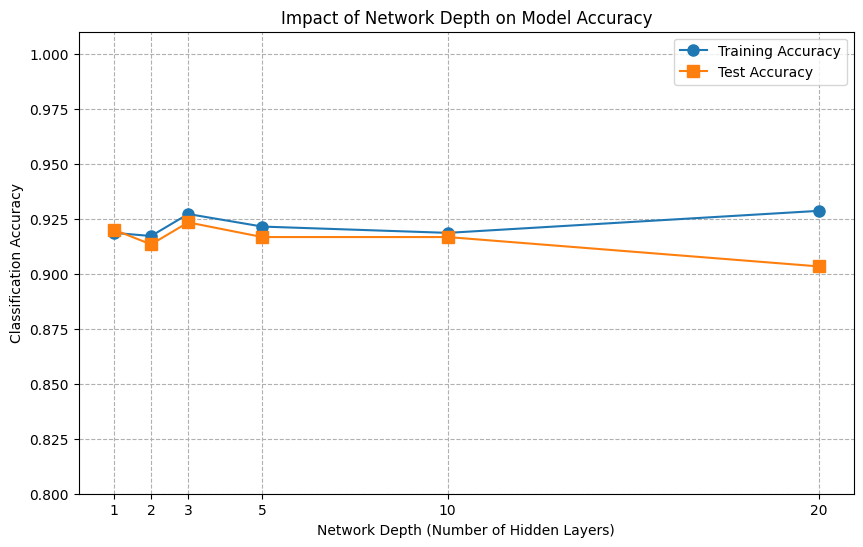

In [ ]:
# 1. Create the Plot
plt.figure(figsize=(10, 6))
plt.plot(depths, train_accuracies, 'o-', label='Training Accuracy', markersize=8)
plt.plot(depths, test_accuracies, 's-', label='Test Accuracy', markersize=8)
plt.xlabel("Network Depth (Number of Hidden Layers)")
plt.ylabel("Classification Accuracy")
plt.title("Impact of Network Depth on Model Accuracy")
plt.legend()
plt.grid(True, linestyle='--')
# Use plt.xticks to ensure all tested depths are shown on the axis
plt.xticks(depths)
plt.ylim(0.8, 1.01) # Set y-axis limits to better visualize the differences
print("\nGenerating plot...")
# Display the plot
plt.show()

In [ ]:
# 2. Create the Table
# Use pandas for a nicely formatted table
results_data = {
    "Network Depth": depths,
    "Final Training Accuracy": [round(acc, 4) for acc in train_accuracies],
    "Final Test Accuracy": [round(acc, 4) for acc in test_accuracies]
}
results_df = pd.DataFrame(results_data)

print("\n--- Summary Table ---")
# .to_string(index=False) prints the DataFrame without the row numbers
print(results_df.to_string(index=False))


--- Summary Table ---
 Network Depth  Final Training Accuracy  Final Test Accuracy
             1                   0.9186               0.9200
             2                   0.9171               0.9133
             3                   0.9271               0.9233
             5                   0.9214               0.9167
            10                   0.9186               0.9167
            20                   0.9286               0.9033
